In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
# Chargement du dataset Zalando Fashion-MNIST (téléchargement automatique ~30 Mo)
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
# Les 10 catégories du catalogue Zalando
class_names = [
'T-shirt/top', 'Pantalon', 'Pull', 'Robe', 'Manteau',
'Sandale', 'Chemise', 'Sneaker', 'Sac', 'Bottine'
]
print("=== EXPLORATION DU CATALOGUE ===")
print(f"Train : {X_train.shape[0]} images de {X_train.shape[1]}x{X_train.shape[2]} pixels")
print(f"Test : {X_test.shape[0]} images")
print(f"Pixels : min={X_train.min()}, max={X_train.max()} (niveaux de gris 0–255)")
print(f"Catégories : {len(class_names)}")
# Distribution des catégories
print("\nDistribution des catégories (train) :")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
  print(f" {class_names[u]:12s} : {c:>5d} articles ({c/len(y_train)*100:.1f}%)")

=== EXPLORATION DU CATALOGUE ===
Train : 60000 images de 28x28 pixels
Test : 10000 images
Pixels : min=0, max=255 (niveaux de gris 0–255)
Catégories : 10

Distribution des catégories (train) :
 T-shirt/top  :  6000 articles (10.0%)
 Pantalon     :  6000 articles (10.0%)
 Pull         :  6000 articles (10.0%)
 Robe         :  6000 articles (10.0%)
 Manteau      :  6000 articles (10.0%)
 Sandale      :  6000 articles (10.0%)
 Chemise      :  6000 articles (10.0%)
 Sneaker      :  6000 articles (10.0%)
 Sac          :  6000 articles (10.0%)
 Bottine      :  6000 articles (10.0%)


In [6]:
# Normalisation : [0, 255] → [0.0, 1.0]
# Les réseaux de neurones convergent mieux avec des valeurs entre 0 et 1
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0
print(f"Après normalisation : min={X_train_norm.min():.1f}, max={X_train_norm.max():.1f}")
# Pour scikit-learn : aplatir chaque image 28x28 en vecteur de 784 valeurs
X_train_flat = X_train_norm.reshape(-1, 784)
X_test_flat = X_test_norm.reshape(-1, 784)
print(f"Forme pour ML classique (aplatie) : {X_train_flat.shape}")
print(f"Forme pour réseau dense (grille) : {X_train_norm.shape}")


Après normalisation : min=0.0, max=1.0
Forme pour ML classique (aplatie) : (60000, 784)
Forme pour réseau dense (grille) : (60000, 28, 28)


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
# Random Forest sur les pixels aplatis (784 features = 784 pixels individuels)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_flat, y_train)
y_pred_rf = rf.predict(X_test_flat)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest — Accuracy : {acc_rf*100:.1f}%")


Random Forest — Accuracy : 87.6%


In [4]:
model_dense = keras.Sequential([
keras.layers.Input(shape=(28, 28)),
keras.layers.Flatten(), # 28x28 → 784
keras.layers.Dense(128, activation='relu'), # Couche cachée 1
keras.layers.Dense(64, activation='relu'), # Couche cachée 2
keras.layers.Dense(10, activation='softmax') # 10 catégories → probabilités
])
model_dense.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy', # Classification multi-classe avec labels entiers
metrics=['accuracy']
)
model_dense.summary()
# Entraînement — 15% du train réservé pour la validation
history_dense = model_dense.fit(
X_train_norm, y_train,
epochs=15,
batch_size=64,
validation_split=0.15,
verbose=1
)


NameError: name 'keras' is not defined

In [ ]:
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)
print(f"Forme pour CNN : {X_train_cnn.shape}") # (60000, 28, 28, 1)
model_cnn = keras.Sequential([
keras.layers.Input(shape=(28, 28, 1)),
# Bloc 1 : détection de motifs simples (contours, bords)
keras.layers.Conv2D(32, (3, 3), activation='relu'), # 32 filtres 3x3
keras.layers.MaxPooling2D((2, 2)), # Réduction spatiale
# Bloc 2 : détection de motifs complexes (formes, structures)
keras.layers.Conv2D(64, (3, 3), activation='relu'), # 64 filtres 3x3
keras.layers.MaxPooling2D((2, 2)), # Réduction spatiale
# Classification finale
keras.layers.Flatten(),
keras.layers.Dense(64, activation='relu'),
keras.layers.Dropout(0.3), # Régularisation anti-overfitting
keras.layers.Dense(10, activation='softmax')
])
model_cnn.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)
model_cnn.summary()
history_cnn = model_cnn.fit(
X_train_cnn, y_train,
epochs=10,
batch_size=64,
validation_split=0.15,
)

Forme pour CNN : (60000, 28, 28, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
318/797 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.5859 - loss: 1.1779

NameError: name 'history_dense' is not defined

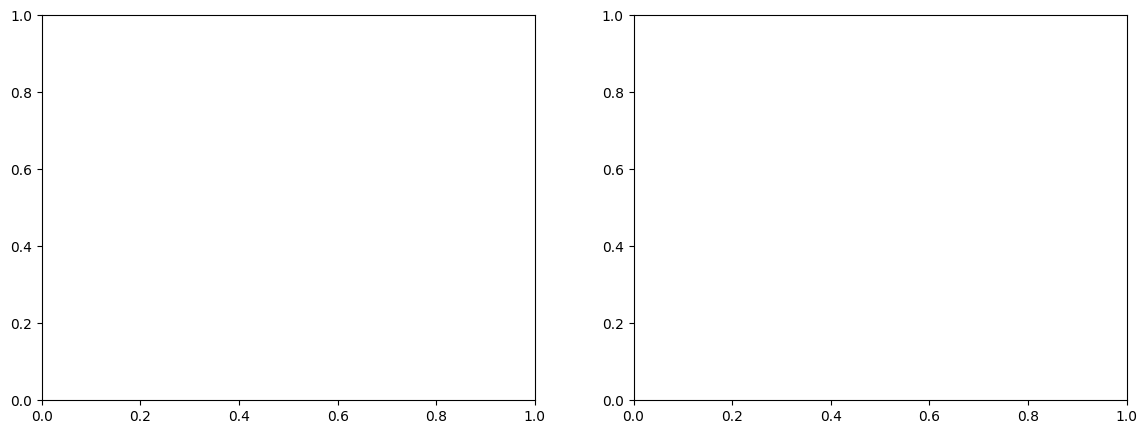

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Réseau dense
axes[0].plot(history_dense.history['accuracy'], 'b-', label='Train')
axes[0].plot(history_dense.history['val_accuracy'], 'r-', label='Validation')
axes[0].set_title('Réseau Dense (MLP)')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# CNN
axes[1].plot(history_cnn.history['accuracy'], 'b-', label='Train')
axes[1].plot(history_cnn.history['val_accuracy'], 'r-', label='Validation')
axes[1].set_title('CNN')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.suptitle('Courbes d\'apprentissage — Diagnostic overfitting', fontsize=13)
plt.tight_layout()
plt.savefig('learning_curves.png')
plt.show()